Can i just go with a CSV like: 
sentence, gensim-tokens(using simple_preprocess, bio-tags-for-the-gensimtokens-column 
"I want Amul dark chocolate right now","I|want|Amul|dark|chocolate|right|now","O|O|B|I|I|O|O" 
So now the flow would be: for all the input sentences, first break them into gensim-tokens then create BIO column

Pipeline steps: 
Using Gensim tokenizer + word2vec:
0) We already have the gensim tokens in the data from previous steps
1) indexing (map tokens to indexes) (this is done using keras tokenizer) 
2) make lookup matrix: index -> word2vec vector

3) Now what, indeally i would have just converted entire sentence to indexes, passed to LSTM using mebedding layer and trained but now I want to go word by word and also append a dense layer and softmax head for BIO classes. I will use tensorflow and keras.
s
4) Train LSTM (use word2vec embedding layer), define no. of epochs and other hyperparameters,epochs, plot validation and training set loss per epoch : 
(i) Pass indexed sequences to LSTM, embedding layers convert word to vector using lookup matrix
5) Inference 

In [31]:
# Imports
import sklearn
import pandas as pd
import numpy as np

# Data Exploration

In [32]:
dataframe = pd.read_csv('./label_token_data_with_BIO_tags.csv')
print(dataframe.head())
print(dataframe.describe())


                                            sentence  label  \
0    I want gift suggestion for general in all gifts      2   
1       I want gift suggestion for wife in all gifts      2   
2  Hi I need to send a birthday scroll to my youn...      2   
3                                           Birthday      2   
4  I want gift suggestion for general for love gifts      2   

                                              tokens  \
0      want|gift|suggestion|for|general|in|all|gifts   
1         want|gift|suggestion|for|wife|in|all|gifts   
2  hi|need|to|send|birthday|scroll|to|my|younger|...   
3                                           birthday   
4    want|gift|suggestion|for|general|for|love|gifts   

                      bio_tags  
0              O|B|O|O|O|O|O|B  
1              O|B|O|O|O|O|O|B  
2  O|O|O|O|B|I|O|O|O|O|O|O|O|O  
3                            O  
4              O|B|O|O|O|O|B|I  
        label
count  1364.0
mean      2.0
std       0.0
min       2.0
25%       2.0
50

Label Distribution:
label
2    1364
Name: count, dtype: int64

Total samples: 1364


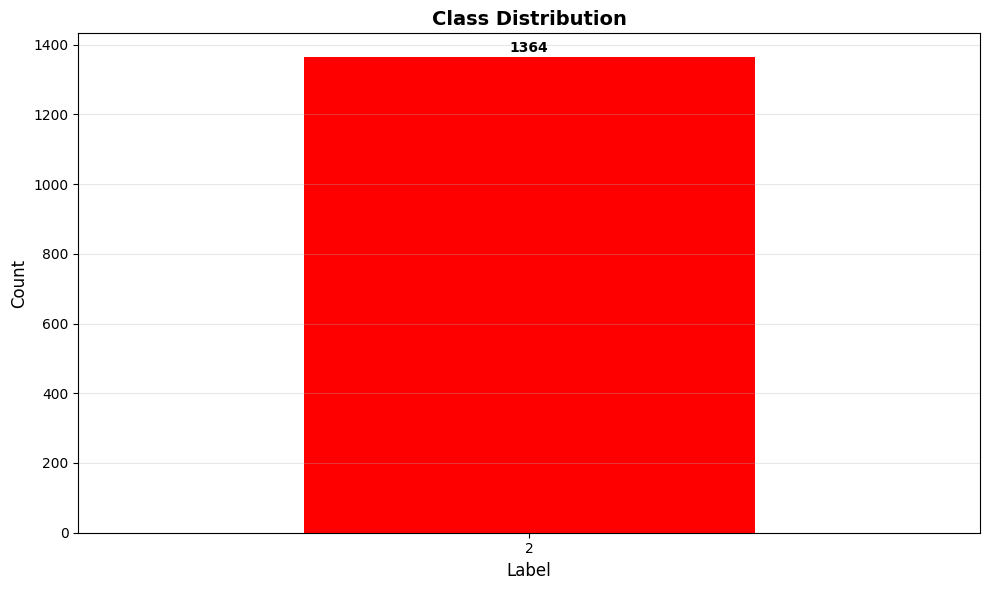


Label Meanings:
-2: Escalate to human agent
-1: Track order/order status (login required)
 1: General conversation/company policy
 2: Product recommendation


In [33]:
import matplotlib.pyplot as plt

# Count label distribution
label_counts = dataframe['label'].value_counts().sort_index()
print("Label Distribution:")
print(label_counts)
print(f"\nTotal samples: {len(dataframe)}")

# Create bar plot
plt.figure(figsize=(10, 6))
label_counts.plot(kind='bar', color=['red', 'orange', 'lightblue', 'green'])
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 5, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print label meanings
print("\nLabel Meanings:")
print("-2: Escalate to human agent")
print("-1: Track order/order status (login required)")
print(" 1: General conversation/company policy")
print(" 2: Product recommendation")

# Pipeline

In [34]:
# Step 0: Preprocessing using gensim.simple_preprocess
# We already have gensim tokens in the 'tokens' column, so we can skip this step.

In [35]:
# Step 1: Indexing using Keras Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

# Parse the tokens column (tokens are stored as pipe-separated strings)
token_lists = dataframe['tokens'].apply(lambda x: x.split('|')).tolist()

print(f"Total sentences: {len(token_lists)}")
print(f"\nExample token lists (first 3):")
for i, tokens in enumerate(token_lists[:3]):
    print(f"  {i+1}. {tokens}")

# Initialize and fit the Keras Tokenizer on the token lists
# Note: We set filters='' to avoid removing any characters since tokens are pre-processed
# We set lower=False since tokens are already lowercased by gensim
tokenizer = Tokenizer(filters='', lower=False, oov_token='<OOV>')

# Fit on pre-tokenized data (pass as space-joined strings)
tokenized_texts = [' '.join(tokens) for tokens in token_lists]
tokenizer.fit_on_texts(tokenized_texts)

# Convert tokens to sequences of indices
sequences = tokenizer.texts_to_sequences(tokenized_texts)

# Get vocabulary info
vocab_size = len(tokenizer.word_index) + 1  # +1 for padding index (0)
print(f"\n" + "=" * 80)
print("Tokenizer Information:")
print("=" * 80)
print(f"Vocabulary size (unique tokens): {len(tokenizer.word_index)}")
print(f"Vocabulary size (with padding): {vocab_size}")

# Show some examples from word_index
print(f"\nFirst 10 tokens in vocabulary (token -> index):")
for i, (word, idx) in enumerate(tokenizer.word_index.items()):
    if i < 10:
        print(f"  {word} -> {idx}")
    else:
        break

# Show sequence information
seq_lengths = [len(seq) for seq in sequences]
print(f"\n" + "=" * 80)
print("Sequence Information:")
print("=" * 80)
print(f"Total sequences: {len(sequences)}")
print(f"Min sequence length: {min(seq_lengths)}")
print(f"Max sequence length: {max(seq_lengths)}")
print(f"Average sequence length: {sum(seq_lengths) / len(seq_lengths):.2f}")

# Show example: tokens -> indices
print(f"\n" + "=" * 80)
print("Example Mappings (tokens -> indices):")
print("=" * 80)
for i in range(3):
    print(f"\nExample {i+1}:")
    print(f"  Original tokens: {token_lists[i]}")
    print(f"  Indexed sequence: {sequences[i]}")
    print(f"  Sequence length: {len(sequences[i])}")


Total sentences: 1364

Example token lists (first 3):
  1. ['want', 'gift', 'suggestion', 'for', 'general', 'in', 'all', 'gifts']
  2. ['want', 'gift', 'suggestion', 'for', 'wife', 'in', 'all', 'gifts']
  3. ['hi', 'need', 'to', 'send', 'birthday', 'scroll', 'to', 'my', 'younger', 'brother', 'on', 'his', 'th', 'birthday']

Tokenizer Information:
Vocabulary size (unique tokens): 1625
Vocabulary size (with padding): 1626

First 10 tokens in vocabulary (token -> index):
  <OOV> -> 1
  for -> 2
  and -> 3
  need -> 4
  you -> 5
  want -> 6
  me -> 7
  gift -> 8
  do -> 9
  show -> 10

Sequence Information:
Total sequences: 1364
Min sequence length: 1
Max sequence length: 15
Average sequence length: 5.13

Example Mappings (tokens -> indices):

Example 1:
  Original tokens: ['want', 'gift', 'suggestion', 'for', 'general', 'in', 'all', 'gifts']
  Indexed sequence: [6, 8, 13, 2, 55, 25, 30, 26]
  Sequence length: 8

Example 2:
  Original tokens: ['want', 'gift', 'suggestion', 'for', 'wife', 'i

In [36]:
# Step 2: Load pretrained Word2Vec and build embedding lookup matrix
import gensim.downloader as api

# Load pretrained Word2Vec model (Google News, 300-dimensional vectors, 3M words)
# This is a famous pretrained model widely used in NLP applications
print("Loading pretrained Word2Vec model (Google News - 300d)...")
print("This may take a few minutes on first download...")
word2vec_model = api.load('word2vec-google-news-300')

print(f"\nPretrained Word2Vec model loaded:")
print(f"  Vocabulary size: {len(word2vec_model)} words")
print(f"  Embedding dimension: {word2vec_model.vector_size}")

# Create embedding matrix: index -> word2vec vector
# Matrix shape: (vocab_size + 1, embedding_dim)
# +1 because index 0 is reserved (for padding)
vocab_size = len(tokenizer.word_index) + 1
embedding_dim = word2vec_model.vector_size
embedding_matrix = np.zeros((vocab_size, embedding_dim))

# Fill the embedding matrix
words_found = 0
words_not_found = 0
words_not_found_list = []

for word, idx in tokenizer.word_index.items():
    if word in word2vec_model:
        embedding_matrix[idx] = word2vec_model[word]
        words_found += 1
    else:
        # Word not in word2vec vocabulary, leave as zeros or initialize randomly
        words_not_found += 1
        if words_not_found <= 10:  # Store first 10 missing words for display
            words_not_found_list.append(word)

print(f"\nEmbedding Matrix created:")
print(f"  Shape: {embedding_matrix.shape}")
print(f"  Vocabulary size (including padding): {vocab_size}")
print(f"  Embedding dimension: {embedding_dim}")
print(f"  Words found in pretrained Word2Vec: {words_found}")
print(f"  Words not found (initialized to zeros): {words_not_found}")
print(f"  Coverage: {100 * words_found / len(tokenizer.word_index):.2f}%")

if words_not_found_list:
    print(f"\n  First few missing words: {words_not_found_list}")

# Show example: word -> index -> vector
print("\n" + "-" * 80)
print("Example word embeddings (first 3 words found in pretrained model):")
print("-" * 80)
count = 0
for word, idx in tokenizer.word_index.items():
    if word in word2vec_model and count < 3:
        print(f"\nWord: '{word}'")
        print(f"Index: {idx}")
        print(f"Vector (first 10 dims): {embedding_matrix[idx][:10]}")
        print(f"Vector shape: {embedding_matrix[idx].shape}")
        count += 1
    if count >= 3:
        break

Loading pretrained Word2Vec model (Google News - 300d)...
This may take a few minutes on first download...

Pretrained Word2Vec model loaded:
  Vocabulary size: 3000000 words
  Embedding dimension: 300

Embedding Matrix created:
  Shape: (1626, 300)
  Vocabulary size (including padding): 1626
  Embedding dimension: 300
  Words found in pretrained Word2Vec: 1591
  Words not found (initialized to zeros): 34
  Coverage: 97.91%

  First few missing words: ['<OOV>', 'and', 'to', 'personalised', 'of', 'customised', 'customise', 'cancelling', 'vanadana', 'poorvika']

--------------------------------------------------------------------------------
Example word embeddings (first 3 words found in pretrained model):
--------------------------------------------------------------------------------

Word: 'for'
Index: 2
Vector (first 10 dims): [-0.01177979 -0.04736328  0.04467773  0.06347656 -0.01818848 -0.06396484
 -0.00131226 -0.07226562  0.06445312  0.08642578]
Vector shape: (300,)

Word: 'need'


In [37]:
# Step 3: Pad sequences to have uniform length
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine max sequence length
max_length = max(seq_lengths)
print(f"Maximum sequence length: {max_length}")

# Pad all sequences to max_length
# padding='post' adds zeros at the end
# truncating='post' truncates from the end if sequence is longer
padded_sequences = pad_sequences(
    sequences, 
    maxlen=max_length, 
    padding='post', 
    truncating='post'
)

print(f"\nPadded sequences shape: {padded_sequences.shape}")
print(f"  Number of samples: {padded_sequences.shape[0]}")
print(f"  Sequence length: {padded_sequences.shape[1]}")

# Show example of padding
print("\n" + "-" * 80)
print("Example of padding:")
print("-" * 80)
for i in range(2):
    print(f"\nOriginal sequence length: {len(sequences[i])}")
    print(f"Original: {sequences[i]}")
    print(f"Padded: {padded_sequences[i]}")
    print(f"Padded length: {len(padded_sequences[i])}")

Maximum sequence length: 15

Padded sequences shape: (1364, 15)
  Number of samples: 1364
  Sequence length: 15

--------------------------------------------------------------------------------
Example of padding:
--------------------------------------------------------------------------------

Original sequence length: 8
Original: [6, 8, 13, 2, 55, 25, 30, 26]
Padded: [ 6  8 13  2 55 25 30 26  0  0  0  0  0  0  0]
Padded length: 15

Original sequence length: 8
Original: [6, 8, 13, 2, 39, 25, 30, 26]
Padded: [ 6  8 13  2 39 25 30 26  0  0  0  0  0  0  0]
Padded length: 15


In [40]:
# Step 4: Build and Train LSTM Model for Entity Extraction (BIO Tagging)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, TimeDistributed, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

print("=" * 80)
print("Step 4: Preparing BIO Tags and Building LSTM Model")
print("=" * 80)

# Parse BIO tags from the dataframe
bio_tag_lists = dataframe['bio_tags'].apply(lambda x: x.split('|')).tolist()

print(f"\nTotal BIO tag sequences: {len(bio_tag_lists)}")
print(f"Example BIO tags (first 3):")
for i in range(3):
    print(f"  {i+1}. Tokens: {token_lists[i]}")
    print(f"     BIO tags: {bio_tag_lists[i]}")

# Create mapping: BIO tag string -> numeric label
bio_tag_to_id = {'O': 0, 'B': 1, 'I': 2}
id_to_bio_tag = {0: 'O', 1: 'B', 2: 'I'}
num_bio_classes = len(bio_tag_to_id)

print(f"\nBIO Tag Mapping:")
print(f"  {bio_tag_to_id}")
print(f"  Number of BIO classes: {num_bio_classes}")

# Convert BIO tags to numeric sequences
bio_sequences = []
for bio_tags in bio_tag_lists:
    bio_seq = [bio_tag_to_id[tag] for tag in bio_tags]
    bio_sequences.append(bio_seq)

# Pad BIO tag sequences to match input sequences
padded_bio_sequences = pad_sequences(
    bio_sequences,
    maxlen=max_length,
    padding='post',
    truncating='post',
    value=0  # Pad with 'O' class
)

print(f"\nPadded BIO sequences shape: {padded_bio_sequences.shape}")

# Show example
print("\nExample of padded BIO sequences:")
for i in range(2):
    print(f"\n  Original tokens: {token_lists[i]}")
    print(f"  Original BIO tags: {bio_tag_lists[i]}")
    print(f"  Padded input sequence: {padded_sequences[i][:15]}...")
    print(f"  Padded BIO sequence: {padded_bio_sequences[i][:15]}...")

# Convert BIO sequences to one-hot encoding for categorical crossentropy
# Shape: (num_samples, max_length, num_bio_classes)
bio_sequences_categorical = to_categorical(padded_bio_sequences, num_classes=num_bio_classes)
print(f"\nCategorical BIO sequences shape: {bio_sequences_categorical.shape}")

# Split data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    padded_sequences,
    bio_sequences_categorical,
    test_size=0.2,
    random_state=42
)

print(f"\nData Split:")
print(f"  Training samples: {X_train.shape[0]}")
print(f"  Validation samples: {X_val.shape[0]}")
print(f"  Input shape: {X_train.shape}")
print(f"  Output shape: {y_train.shape}")

# Build LSTM model with TimeDistributed Dense layer for sequence labeling
print("\n" + "=" * 80)
print("Building LSTM Model Architecture")
print("=" * 80)

model = Sequential([
    # Embedding layer: use pretrained word2vec embeddings
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False,  # Freeze pretrained embeddings
        name='word2vec_embedding'
    ),
    
    # Bidirectional LSTM layer with return_sequences=True for token-level output
    # Bidirectional helps capture context from both directions
    Bidirectional(LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2), name='bilstm_1'),
    
    # Another Bidirectional LSTM layer for deeper representation
    Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.2), name='bilstm_2'),
    
    # TimeDistributed Dense layer: applies Dense layer to each timestep independently
    # This gives us a BIO prediction for each token in the sequence
    TimeDistributed(Dense(num_bio_classes, activation='softmax'), name='bio_classifier')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nModel Architecture:")
model.summary()

print("\n" + "=" * 80)
print("Model built successfully!")
print("=" * 80)
print("\nKey Features:")
print("  - Uses pretrained Word2Vec embeddings (frozen)")
print("  - Bidirectional LSTM captures context from both directions")
print("  - TimeDistributed Dense layer predicts BIO tag for each token")
print("  - Trained with BPTT (Backpropagation Through Time)")
print("  - Output: (batch_size, sequence_length, 3) for O, B, I classes")

Step 4: Preparing BIO Tags and Building LSTM Model

Total BIO tag sequences: 1364
Example BIO tags (first 3):
  1. Tokens: ['want', 'gift', 'suggestion', 'for', 'general', 'in', 'all', 'gifts']
     BIO tags: ['O', 'B', 'O', 'O', 'O', 'O', 'O', 'B']
  2. Tokens: ['want', 'gift', 'suggestion', 'for', 'wife', 'in', 'all', 'gifts']
     BIO tags: ['O', 'B', 'O', 'O', 'O', 'O', 'O', 'B']
  3. Tokens: ['hi', 'need', 'to', 'send', 'birthday', 'scroll', 'to', 'my', 'younger', 'brother', 'on', 'his', 'th', 'birthday']
     BIO tags: ['O', 'O', 'O', 'O', 'B', 'I', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']

BIO Tag Mapping:
  {'O': 0, 'B': 1, 'I': 2}
  Number of BIO classes: 3

Padded BIO sequences shape: (1364, 15)

Example of padded BIO sequences:

  Original tokens: ['want', 'gift', 'suggestion', 'for', 'general', 'in', 'all', 'gifts']
  Original BIO tags: ['O', 'B', 'O', 'O', 'O', 'O', 'O', 'B']
  Padded input sequence: [ 6  8 13  2 55 25 30 26  0  0  0  0  0  0  0]...
  Padded BIO sequence: [

/Users/geetansh/Desktop/verve/chatbot/venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ word2vec_embedding (Embedding)  │ ?                      │       487,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bio_classifier                  │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 487,800 (1.86 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 487,800 (1.86 MB)


Model built successfully!

Key Features:
  - Uses pretrained Word2Vec embeddings (frozen)
  - Bidirectional LSTM captures context from both directions
  - TimeDistributed Dense layer predicts BIO tag for each token
  - Trained with BPTT (Backpropagation Through Time)
  - Output: (batch_size, sequence_length, 3) for O, B, I classes


In [41]:
# Step 5: Train the LSTM Model
print("Training LSTM model for entity extraction...")
print("=" * 80)

# Define callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
# BPTT (Backpropagation Through Time) is handled automatically by Keras/TensorFlow
# The LSTM will process sequences token-by-token and learn to predict BIO tags
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

print("\n" + "=" * 80)
print("Training completed!")
print("=" * 80)

Training LSTM model for entity extraction...
Epoch 1/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 8s 63ms/step - accuracy: 0.8486 - loss: 0.5211 - val_accuracy: 0.8611 - val_loss: 0.3195
Epoch 2/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8979 - loss: 0.2429 - val_accuracy: 0.9385 - val_loss: 0.1650
Epoch 3/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.9606 - loss: 0.1153 - val_accuracy: 0.9705 - val_loss: 0.0906
Epoch 4/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9803 - loss: 0.0689 - val_accuracy: 0.9822 - val_loss: 0.0615
Epoch 5/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9869 - loss: 0.0461 - val_accuracy: 0.9844 - val_loss: 0.0517
Epoch 6/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step - accuracy: 0.9891 - loss: 0.0383 - val_accuracy: 0.9858 - val_loss: 0.0487
Epoch 7/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.9896 - loss: 0.0338 - val_accuracy: 0.9873 - val_loss: 0.0421
Epoch 8/50
35/35 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.9

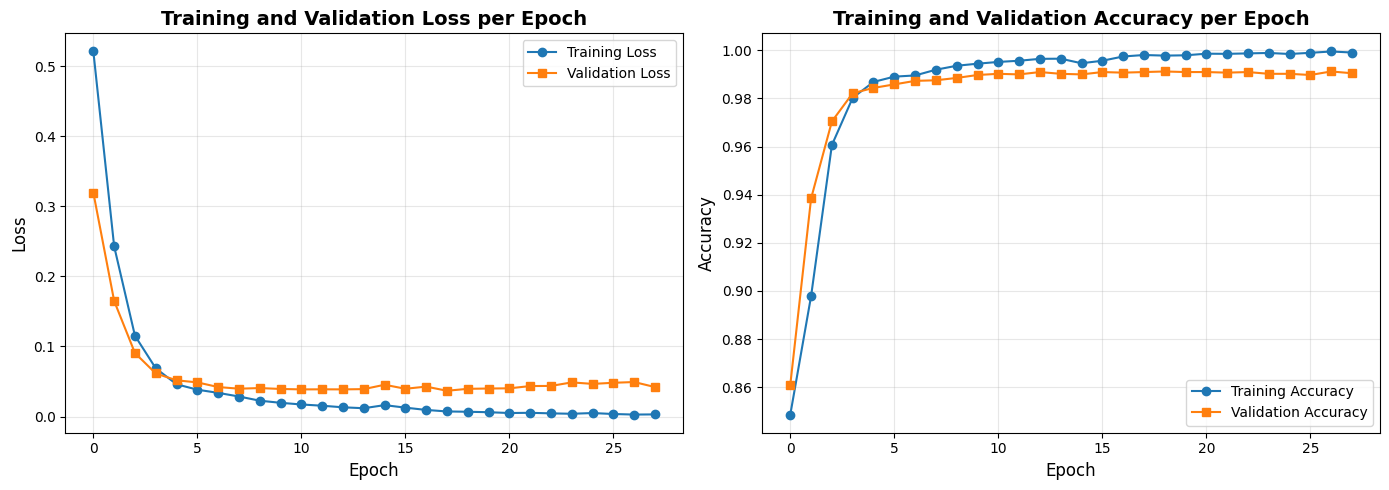


Final Training Metrics:
  Training Loss: 0.0030
  Training Accuracy: 0.9991
  Validation Loss: 0.0421
  Validation Accuracy: 0.9905


In [42]:
# Plot training and validation loss per epoch
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss per Epoch', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

# Plot accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Training and Validation Accuracy per Epoch', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print final metrics
print("\nFinal Training Metrics:")
print(f"  Training Loss: {history.history['loss'][-1]:.4f}")
print(f"  Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"  Validation Loss: {history.history['val_loss'][-1]:.4f}")
print(f"  Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [43]:
# Step 6: Inference Function for Entity Extraction
from gensim.utils import simple_preprocess

def extract_entities(sentence):
    """
    Extracts entities from a sentence using the trained LSTM model with BIO tagging.
    
    Args:
        sentence (str): Input sentence to extract entities from
    
    Returns:
        dict: Contains tokens, BIO predictions, and extracted entities
    """
    # Step 1: Preprocess the sentence (tokenize using gensim)
    tokens = simple_preprocess(sentence, deacc=True)
    
    if len(tokens) == 0:
        return {
            'sentence': sentence,
            'tokens': [],
            'bio_tags': [],
            'entities': []
        }
    
    # Step 2: Convert tokens to space-joined text for tokenizer
    preprocessed_text = ' '.join(tokens)
    
    # Step 3: Convert to sequence of indices
    sequence = tokenizer.texts_to_sequences([preprocessed_text])
    
    # Step 4: Pad the sequence
    padded = pad_sequences(sequence, maxlen=max_length, padding='post', truncating='post')
    
    # Step 5: Make prediction
    predictions = model.predict(padded, verbose=0)  # Shape: (1, max_length, 3)
    
    # Step 6: Get predicted BIO tags for each token
    # Take argmax to get the class with highest probability
    predicted_bio_ids = np.argmax(predictions[0], axis=-1)  # Shape: (max_length,)
    
    # Convert IDs back to BIO tags (only for actual tokens, not padding)
    predicted_bio_tags = [id_to_bio_tag[bio_id] for bio_id in predicted_bio_ids[:len(tokens)]]
    
    # Step 7: Extract entities from BIO tags
    entities = []
    current_entity = []
    
    for i, (token, bio_tag) in enumerate(zip(tokens, predicted_bio_tags)):
        if bio_tag == 'B':  # Begin new entity
            if current_entity:  # Save previous entity if exists
                entities.append(' '.join(current_entity))
            current_entity = [token]
        elif bio_tag == 'I':  # Inside entity
            if current_entity:  # Continue current entity
                current_entity.append(token)
            else:  # I without B, treat as new entity (error recovery)
                current_entity = [token]
        else:  # bio_tag == 'O' (Outside entity)
            if current_entity:  # End current entity
                entities.append(' '.join(current_entity))
                current_entity = []
    
    # Don't forget the last entity if sentence ends with an entity
    if current_entity:
        entities.append(' '.join(current_entity))
    
    return {
        'sentence': sentence,
        'tokens': tokens,
        'bio_tags': predicted_bio_tags,
        'entities': entities,
        'token_tag_pairs': list(zip(tokens, predicted_bio_tags))
    }

print("Entity extraction function ready!")
print("\nUsage: extract_entities('your sentence here')")

# Test the inference function with example sentences
test_sentences = [
    "I want Amul dark chocolate right now",
    "I want gift suggestion for wife in all gifts",
    "Hi I need to send a birthday scroll to my younger brother",
    "I want gift suggestion for boyfriend for birthday",
    "Can you recommend a good smartphone under 20000 rupees",
    "I need Cadbury Dairy Milk and some flowers"
]

print("\n" + "=" * 80)
print("Testing Entity Extraction:")
print("=" * 80)

for sentence in test_sentences:
    result = extract_entities(sentence)
    print(f"\nSentence: {result['sentence']}")
    print(f"Tokens: {result['tokens']}")
    print(f"BIO Tags: {result['bio_tags']}")
    print(f"Token-Tag Pairs:")
    for token, tag in result['token_tag_pairs']:
        print(f"  {token:20s} -> {tag}")
    print(f"Extracted Entities: {result['entities']}")
    print("-" * 80)

Entity extraction function ready!

Usage: extract_entities('your sentence here')

Testing Entity Extraction:

Sentence: I want Amul dark chocolate right now
Tokens: ['want', 'amul', 'dark', 'chocolate', 'right', 'now']
BIO Tags: ['O', 'O', 'O', 'B', 'O', 'O']
Token-Tag Pairs:
  want                 -> O
  amul                 -> O
  dark                 -> O
  chocolate            -> B
  right                -> O
  now                  -> O
Extracted Entities: ['chocolate']
--------------------------------------------------------------------------------

Sentence: I want gift suggestion for wife in all gifts
Tokens: ['want', 'gift', 'suggestion', 'for', 'wife', 'in', 'all', 'gifts']
BIO Tags: ['O', 'B', 'O', 'O', 'O', 'O', 'O', 'B']
Token-Tag Pairs:
  want                 -> O
  gift                 -> B
  suggestion           -> O
  for                  -> O
  wife                 -> O
  in                   -> O
  all                  -> O
  gifts                -> B
Extracted Entiti

In [44]:
# Interactive Entity Extraction
print("Interactive Entity Extraction")
print("=" * 80)
print("Enter sentences to extract entities. Type 'exit' to quit.\n")

while True:
    user_input = input("Enter a sentence: ")
    if user_input.lower() == 'exit':
        print("Exiting entity extraction.")
        break
    
    result = extract_entities(user_input)
    print(f"\nTokens and BIO Tags:")
    for token, tag in result['token_tag_pairs']:
        print(f"  {token:20s} -> {tag}")
    print(f"\nExtracted Entities: {result['entities']}")
    print("-" * 80)

Interactive Entity Extraction
Enter sentences to extract entities. Type 'exit' to quit.


Tokens and BIO Tags:
  want                 -> O
  amul                 -> B
  dark                 -> B
  chocolate            -> I

Extracted Entities: ['amul', 'dark chocolate']
--------------------------------------------------------------------------------

Tokens and BIO Tags:
  want                 -> O
  amul                 -> O
  dark                 -> O
  chocolate            -> B
  and                  -> O
  pair                 -> O
  of                   -> O
  blue                 -> B
  jeans                -> I
  with                 -> O
  leather              -> B
  shoes                -> I

Extracted Entities: ['chocolate', 'blue jeans', 'leather shoes']
--------------------------------------------------------------------------------

Tokens and BIO Tags:
  need                 -> O
  lenovo               -> O
  legion               -> O
  laptop               -> B

Extracte

# Save Model and Artifacts

In [ ]:
# Save the trained model and artifacts for entity extraction
import pickle

print("Saving model and artifacts...")
print("=" * 80)

# Save the model
model.save('lstm_entity_extraction.keras')
print("✓ Model saved as 'lstm_entity_extraction.keras'")

# Save the tokenizer
with open('entity_tokenizer.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)
print("✓ Tokenizer saved as 'entity_tokenizer.pkl'")

# Save model configuration and BIO mappings
model_config = {
    'max_length': max_length,
    'vocab_size': vocab_size,
    'embedding_dim': embedding_dim,
    'num_bio_classes': num_bio_classes,
    'bio_tag_to_id': bio_tag_to_id,
    'id_to_bio_tag': id_to_bio_tag
}

with open('entity_model_config.pkl', 'wb') as f:
    pickle.dump(model_config, f)
print("✓ Model configuration saved as 'entity_model_config.pkl'")

print("\n" + "=" * 80)
print("All artifacts saved successfully!")
print("=" * 80)
print("\nSaved files:")
print("  1. lstm_entity_extraction.keras - Trained LSTM model")
print("  2. entity_tokenizer.pkl - Keras tokenizer")
print("  3. entity_model_config.pkl - Configuration and BIO mappings")

✓ Model saved as 'lstm_intent_classifier.keras'
✓ Tokenizer saved as 'tokenizer.pkl'
✓ Model configuration saved as 'model_config.pkl'

All artifacts saved successfully!


# Load Model and Run Inference (Fresh Start)

In [ ]:
# FRESH START: Load entity extraction model and run inference
# This code can be run in a fresh Python session/notebook

import numpy as np
import pickle
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from gensim.utils import simple_preprocess

print("Loading saved entity extraction model and artifacts...")
print("=" * 80)

# Load the trained model
loaded_model = load_model('lstm_entity_extraction.keras')
print("✓ Model loaded from 'lstm_entity_extraction.keras'")

# Load the tokenizer
with open('entity_tokenizer.pkl', 'rb') as f:
    loaded_tokenizer = pickle.load(f)
print("✓ Tokenizer loaded from 'entity_tokenizer.pkl'")

# Load model configuration
with open('entity_model_config.pkl', 'rb') as f:
    loaded_config = pickle.load(f)
print("✓ Configuration loaded from 'entity_model_config.pkl'")

print("\nModel Configuration:")
print(f"  Max sequence length: {loaded_config['max_length']}")
print(f"  Vocabulary size: {loaded_config['vocab_size']}")
print(f"  Embedding dimension: {loaded_config['embedding_dim']}")
print(f"  Number of BIO classes: {loaded_config['num_bio_classes']}")
print(f"  BIO tag mapping: {loaded_config['bio_tag_to_id']}")
print("=" * 80)

Loading saved model and artifacts...
✓ Model loaded from 'lstm_intent_classifier.keras'
✓ Tokenizer loaded from 'tokenizer.pkl'
✓ Configuration loaded from 'model_config.pkl'

Model Configuration:
  Max sequence length: 33
  Vocabulary size: 1332
  Embedding dimension: 300


In [ ]:
# Define inference function using loaded artifacts
def extract_entities_from_loaded_model(sentence):
    """
    Extracts entities from a sentence using the loaded LSTM model.
    
    Args:
        sentence (str): Input sentence to extract entities from
    
    Returns:
        dict: Contains tokens, BIO predictions, and extracted entities
    """
    # Step 1: Preprocess the sentence (tokenize using gensim)
    tokens = simple_preprocess(sentence, deacc=True)
    
    if len(tokens) == 0:
        return {
            'sentence': sentence,
            'tokens': [],
            'bio_tags': [],
            'entities': []
        }
    
    # Step 2: Convert tokens to space-joined text for tokenizer
    preprocessed_text = ' '.join(tokens)
    
    # Step 3: Convert to sequence of indices
    sequence = loaded_tokenizer.texts_to_sequences([preprocessed_text])
    
    # Step 4: Pad the sequence
    padded = pad_sequences(
        sequence,
        maxlen=loaded_config['max_length'],
        padding='post',
        truncating='post'
    )
    
    # Step 5: Make prediction
    predictions = loaded_model.predict(padded, verbose=0)  # Shape: (1, max_length, 3)
    
    # Step 6: Get predicted BIO tags for each token
    predicted_bio_ids = np.argmax(predictions[0], axis=-1)
    
    # Convert IDs back to BIO tags (only for actual tokens)
    id_to_bio_tag = loaded_config['id_to_bio_tag']
    predicted_bio_tags = [id_to_bio_tag[bio_id] for bio_id in predicted_bio_ids[:len(tokens)]]
    
    # Step 7: Extract entities from BIO tags
    entities = []
    current_entity = []
    
    for i, (token, bio_tag) in enumerate(zip(tokens, predicted_bio_tags)):
        if bio_tag == 'B':  # Begin new entity
            if current_entity:
                entities.append(' '.join(current_entity))
            current_entity = [token]
        elif bio_tag == 'I':  # Inside entity
            if current_entity:
                current_entity.append(token)
            else:
                current_entity = [token]
        else:  # 'O' (Outside entity)
            if current_entity:
                entities.append(' '.join(current_entity))
                current_entity = []
    
    # Don't forget the last entity
    if current_entity:
        entities.append(' '.join(current_entity))
    
    return {
        'sentence': sentence,
        'tokens': tokens,
        'bio_tags': predicted_bio_tags,
        'entities': entities,
        'token_tag_pairs': list(zip(tokens, predicted_bio_tags))
    }

print("✓ Entity extraction function ready!")
print("\nUsage: extract_entities_from_loaded_model('your sentence here')")

✓ Inference function ready!

Usage: predict_intent_from_loaded_model('your sentence here')


In [ ]:
# Interactive Entity Extraction (using loaded model)
print("Interactive Entity Extraction (Loaded Model)")
print("=" * 80)
print("Enter sentences to extract entities. Type 'exit' to quit.\n")

while True:
    user_input = input("Enter a sentence: ")
    if user_input.lower() == 'exit':
        print("Exiting entity extraction.")
        break
    
    result = extract_entities_from_loaded_model(user_input)
    print(f"\nTokens and BIO Tags:")
    for token, tag in result['token_tag_pairs']:
        print(f"  {token:20s} -> {tag}")
    print(f"\nExtracted Entities: {result['entities']}")
    print("-" * 80)


Predicted Label: 1 - General conversation/company policy
Confidence: 91.45%
Probabilities:
  -2 (Escalate): 0.0473
  -1 (Track order): 0.0099
  1 (Conversation): 0.9145
  2 (Recommendation): 0.0283

Predicted Label: 1 - General conversation/company policy
Confidence: 91.83%
Probabilities:
  -2 (Escalate): 0.0466
  -1 (Track order): 0.0091
  1 (Conversation): 0.9183
  2 (Recommendation): 0.0259

Predicted Label: -1 - Track order/order status (login required)
Confidence: 93.92%
Probabilities:
  -2 (Escalate): 0.0034
  -1 (Track order): 0.9392
  1 (Conversation): 0.0566
  2 (Recommendation): 0.0008
Exiting inference loop.
